# 🌲 04 — Nonlinear Modeling

Exploring nonlinearity using Random Forest to improve air quality predictions.

## 🧠 01 — Notebook Metadata

Description:

- Define notebook metadata, objective, and model overview.

In [2]:
import platform
from colorama import Fore, Style
from sklearn import __version__ as sklearn_version

In [3]:
# === Basic Information ===
NOTEBOOK_NAME = "04_Nonlinear_Modeling"
STEP = "01 - Notebook Metadata"
AUTHOR = "Chgwyellow"
DATE = "2025-11-11"
MODEL = "Random Forest Regressor"

# === Display Environment Info ===
print(Fore.CYAN + f"📘 Notebook: {NOTEBOOK_NAME}")
print(Fore.CYAN + f"🔹 Step: {STEP}")
print(Fore.CYAN + f"👨‍💻 Author: {AUTHOR}")
print(Fore.CYAN + f"📅 Date: {DATE}")
print(Fore.CYAN + f"🌲 Model: {MODEL}")
print(Style.RESET_ALL)

print(Fore.YELLOW + "🧩 Environment Information:")
print(Fore.YELLOW + f"Python Version: {platform.python_version()}")
print(Fore.YELLOW + f"Scikit-learn Version: {sklearn_version}")
print(Fore.YELLOW + f"System Platform: {platform.system()} {platform.release()}")
print(Style.RESET_ALL)

📘 Notebook: 04_Nonlinear_Modeling
🔹 Step: 01 - Notebook Metadata
👨‍💻 Author: Chgwyellow
📅 Date: 2025-11-11
🌲 Model: Random Forest Regressor

🧩 Environment Information:
Python Version: 3.13.8
Scikit-learn Version: 1.7.2
System Platform: Windows 11



## 📂 02 — Load and Prepare Data

Description:

- Load the cleaned dataset, confirm data structure, and perform preprocessing consistent with prior chapters

In [4]:
from src.modeling.train_baseline import load_cleaned_data, build_features
from src.features.feature_engineering import (
    add_rolling_features,
    clip_pollutants,
    handle_outliers_iqr,
    log_transform_features,
    scale_features,
)
from src.utils.emoji_log import success, info, warn, save

In [5]:
# === 1. Load Cleaned Data ===
filename = "Taiwan"
df = load_cleaned_data(filename)

📂 Loading CSV: C:\Users\dinni\OneDrive\桌面\air_pollution\data\processed\Taiwan.csv
✅ Read CSV successfully! Shape: (5823862, 25)


In [6]:
# === Initial Check ===
df.head()

,date,sitename,county,aqi,status,so2,co,o3,o3_8hr,pm10,...,winddirec,co_8hr,longitude,latitude,year,month,day,weekday,hour,season
0,2024-08-31 23:00:00,Hukou,Hsinchu_County,62.0,Moderate,0.9,0.17,35.0,40.2,18.0,...,225.0,0.2,121.038869,24.900097,2024,8,31,5,23,Summer
1,2024-08-31 23:00:00,Zhongming,Taichung_City,50.0,Good,1.6,0.32,27.9,35.1,27.0,...,184.0,0.2,120.641092,24.151958,2024,8,31,5,23,Summer
2,2024-08-31 23:00:00,Zhudong,Hsinchu_County,45.0,Good,0.4,0.17,25.1,40.6,21.0,...,210.0,0.2,121.088955,24.740914,2024,8,31,5,23,Summer
3,2024-08-31 23:00:00,Hsinchu,Hsinchu_City,42.0,Good,0.8,0.20,30.0,35.9,19.0,...,239.0,0.2,120.972368,24.805636,2024,8,31,5,23,Summer
4,2024-08-31 23:00:00,Toufen,Miaoli_County,50.0,Good,1.0,0.16,33.5,35.9,18.0,...,259.0,0.1,120.898693,24.696907,2024,8,31,5,23,Summer


In [7]:
df.isna().sum().sort_values(ascending=False).head(10)

status    92897
pm10        255
pm2.5        71
nox          25
no2          25
no           25
o3_8hr       21
co           21
o3           21
so2          21
dtype: int64

In [6]:
# === 2. Apply preprocessing pipeline
df_clip = clip_pollutants(df)
df_rolling = add_rolling_features(df_clip)
df_iqr = handle_outliers_iqr(df_rolling)
df_log = log_transform_features(df_iqr)

success("Preprocessing has been finished.")

✅ The pollutants limit has been set.
⚠️ Skipping nox due to NO + NO2 already exist.
✅ Rolling features added.
✅ IQR has been set.
✅ Pollutants skewes has been smoothed.
✅ Preprocessing has been finished.


In [7]:
# === 3. Build features and target ===
X, y = build_features(df_log)
X_scaled = scale_features(X, save_=False)

💬 Features shape: (5823862, 32), Target shape: (5823862,)
✅ Numerical features have been standardized. (32 columns scaled)


In [9]:
# === 4. Quick sanity check ===
X_scaled.head()

,so2,co,o3,o3_8hr,pm10,pm2.5,no2,no,windspeed,winddirec,...,o3_rolling_3d,o3_rolling_7d,pm10_rolling_3d,pm10_rolling_7d,pm2.5_rolling_3d,pm2.5_rolling_7d,no2_rolling_3d,no2_rolling_7d,no_rolling_3d,no_rolling_7d
0,-0.845970,-0.910475,0.489435,0.637436,-0.585287,0.361067,-1.540600,-1.341426,0.052749,0.542878,...,0.272859,0.296664,-0.701859,-0.731087,0.014999,0.015603,-1.077791,-1.142411,-0.402446,-0.435943
54,-0.160504,-0.506459,1.169608,2.069311,-0.665053,0.507598,-2.263177,0.062675,-0.491846,-1.266198,...,1.599524,1.738980,-0.744761,-0.775778,0.180760,0.187943,-1.234452,-1.308468,-0.223921,-0.242555
62,-1.608728,-0.841720,0.537781,0.764151,-0.369001,-0.456403,-0.999949,-1.341426,-0.673377,-1.292934,...,0.346879,0.377137,-0.573151,-0.597015,-0.648046,-0.673757,-0.897028,-0.950806,-0.402446,-0.435943
61,-1.123781,-0.311783,-0.068833,0.529729,-0.585287,-0.766742,0.492132,-0.420123,-0.794398,-0.187882,...,-0.416095,-0.452350,-0.701859,-0.731087,-0.813807,-0.846097,0.151397,0.160498,-0.300432,-0.325436
60,-0.160504,-0.841720,0.451043,0.675450,-1.035821,-1.166839,-0.803522,-0.245358,-0.854908,-1.141435,...,0.215921,0.234762,-0.916371,-0.954540,-0.979569,-1.018437,-0.812672,-0.861391,-0.274928,-0.297809


In [10]:
y.head()

0     62.0
54    74.0
62    43.0
61    41.0
60    37.0
Name: aqi, dtype: float64

## 🧮 03 — Feature Selection and Scaling

Description:

- Select final features for Random Forest input, validate data distribution, and ensure consistent scaling from the previous step.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# === 1. Basic shape check ===
info(f"X_scaled shape: {X_scaled.shape}")
info(f"y shape: {y.shape}")

💬 X_scaled shape: (5823862, 32)
💬 y shape: (5823862,)


In [10]:
# === 2. Check variance of each feature ===
variance = X_scaled.var().sort_values()
low_var_cols = variance[variance < 1e-4]

if len(low_var_cols) > 0:
    warn(f"Found {len(low_var_cols)} low-variance features: {low_var_cols}")
else:
    success("No low-variance features found.")

✅ No low-variance features found.


In [11]:
# === 3. High Correlation Check ===
corr_matrix = X_scaled.corr()

# |corr| > 0.9
threshold = 0.9
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
high_corr_pairs = (
    corr_matrix.where(mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"].abs() > threshold]

In [12]:
if not high_corr_pairs.empty:
    warn(f"Found {len(high_corr_pairs)} highly correlated feature pairs (>|{threshold}|)")
    display(high_corr_pairs.sort_values(by="Correlation", ascending=False))
else:
    success("No highly correlated feature pairs found.")

⚠️ Found 7 highly correlated feature pairs (>|0.9|)


,Feature_1,Feature_2,Correlation
481,pm2.5_rolling_3d,pm2.5_rolling_7d,0.957921
468,pm10_rolling_3d,pm10_rolling_7d,0.955388
490,no2_rolling_3d,no2_rolling_7d,0.936491
430,co_rolling_3d,co_rolling_7d,0.920547
495,no_rolling_3d,no_rolling_7d,0.914961
451,o3_rolling_3d,o3_rolling_7d,0.907123
405,so2_rolling_3d,so2_rolling_7d,0.901308


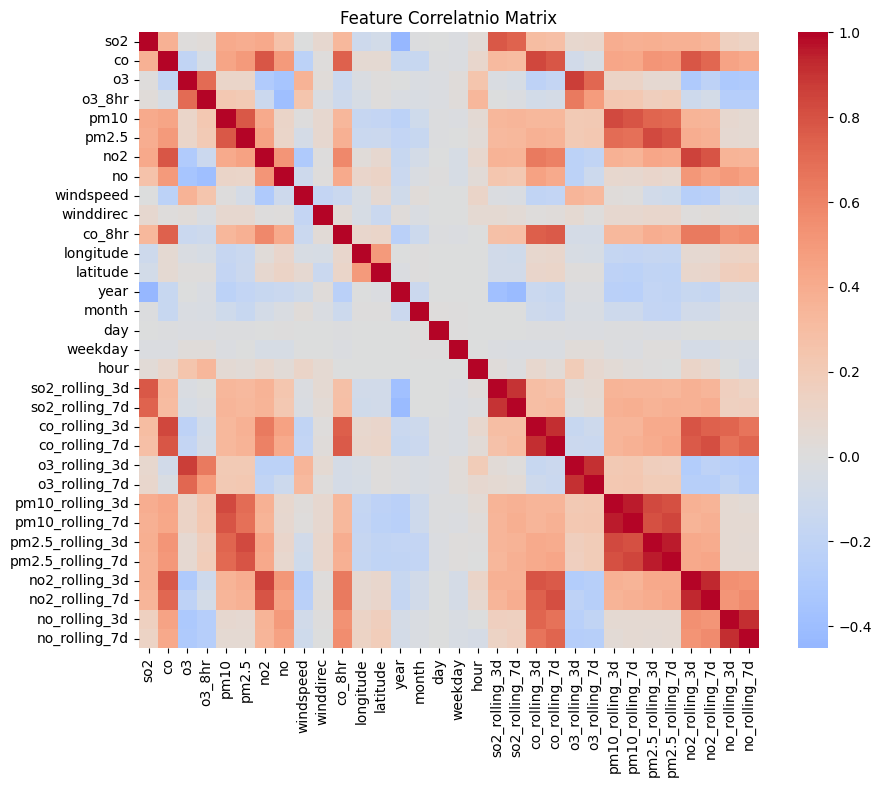

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlatnio Matrix")
plt.show()

In [14]:
# === 4. Visualize Scaled Feature Distributions ===
n_features_to_plot = min(6, X_scaled.shape[1])
sample_feature = np.random.choice(X_scaled.columns, size=n_features_to_plot, replace=False)
info(f"Visualizing {n_features_to_plot} randomly selected features:")
sample_feature

💬 Visualizing 6 randomly selected features:


array(['so2_rolling_3d', 'so2_rolling_7d', 'pm10_rolling_3d',
       'pm2.5_rolling_7d', 'weekday', 'no_rolling_3d'], dtype=object)

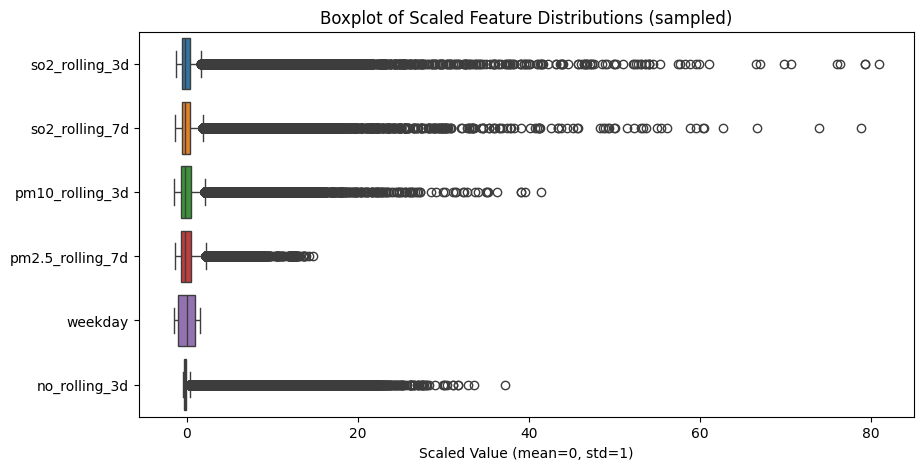

In [15]:
# Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=X_scaled[sample_feature], orient="h")
plt.title("Boxplot of Scaled Feature Distributions (sampled)")
plt.xlabel("Scaled Value (mean=0, std=1)")
plt.show()

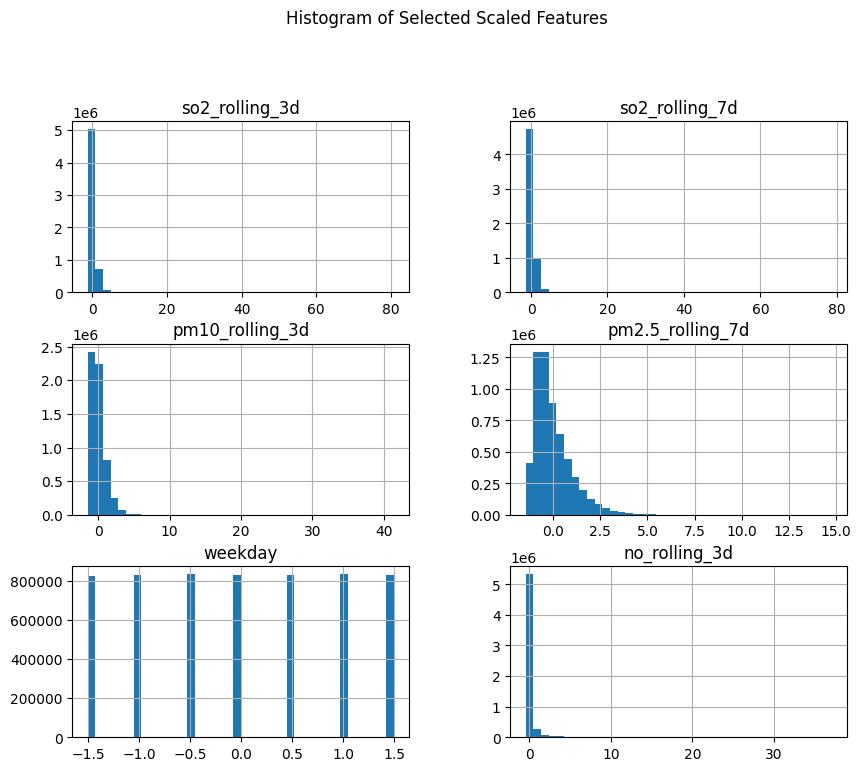

In [16]:
# Histogram
X_scaled[sample_feature].hist(figsize=(10, 8), bins=40)
plt.suptitle("Histogram of Selected Scaled Features", y=1.02)
plt.show()

## 🌳 04 — Build Random Forest Regressor

Description:

- Initialize the Random Forest model with base hyperparameters and train it using the training set.

In [17]:
# === 1. Initialize and Train Random Forest ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
info(f"Training sets: {X_train.shape}, Testing sets: {X_test.shape}")

💬 Training sets: (4659089, 32), Testing sets: (1164773, 32)


In [21]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    max_samples=0.3,
    random_state=42,
    n_jobs=-1
)
success("Random Forest initialized with base parameters.")

✅ Random Forest initialized with base parameters.


In [22]:
rf_model.fit(X_train, y_train)
success("Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [18]:
# === 2. — Save Trained Model ===
import joblib
import datetime
from src.config import MODEL_DIR

In [35]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
model_path = MODEL_DIR / f"RandomForestRegressor_{timestamp}.pkl"
joblib.dump(rf_model, model_path)
save(f"RandomForestRegressor model saved at {model_path}")

💾 RandomForestRegressor model saved at C:\Users\dinni\OneDrive\桌面\air_pollution\models\RandomForestRegressor_20251111_2302.pkl


## 🔍 05 — Model Evaluation

Description:

- Evaluate model performance using MAE, RMSE, and R² metrics.

In [19]:
model_path = MODEL_DIR / "RandomForestRegressor_20251111_2302.pkl"
rf_model = joblib.load(model_path)

In [20]:
# === 1. — Evaluate Model Performance ===
import json
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [31]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics = {"MAE": mae, "RMSE": rmse, "r2": r2}
info(f"RF Model Results: {metrics}")

💬 RF Model Results: {'MAE': 6.034270196100234, 'RMSE': 9.162841553845057, 'r2': 0.9053746739161099}


In [32]:
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
metrics_path = MODEL_DIR / f"RandomForestRegressor_metrics_{timestamp}.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)
save(f"Metrics saved at {metrics_path}")

💾 Metrics saved at C:\Users\dinni\OneDrive\桌面\air_pollution\models\RandomForestRegressor_metrics_20251112_0118.json


## ⚖️ 06 — Compare with Baseline Model

Description:

- Compare Random Forest performance against the Linear Regression baseline model.

In [28]:
# === 1. Load baseline metrics ===
baseline_path = MODEL_DIR / "baseline_metrics_20251110_2322.json"
with open(baseline_path, "r", encoding="utf-8") as f:
    baseline_metrics = json.load(f)
baseline_metrics

{'MAE': 9.253898988441248,
 'RMSE': 13.053055435419665,
 'r2': 0.8079689747637755}

In [33]:
# === 2. Load Random Forest metrics ===
rf_path = MODEL_DIR / "RandomForestRegressor_metrics_20251112_0118.json"
with open(rf_path, "r", encoding="utf-8") as f:
    rf_metrics = json.load(f)
rf_metrics

{'MAE': 6.034270196100234, 'RMSE': 9.162841553845057, 'r2': 0.9053746739161099}

In [34]:
compared_df = pd.DataFrame([baseline_metrics, rf_metrics], index=["Linear Regression", "Random Forest"])
compared_df

,MAE,RMSE,r2
Linear Regression,9.253899,13.053055,0.807969
Random Forest,6.034270,9.162842,0.905375


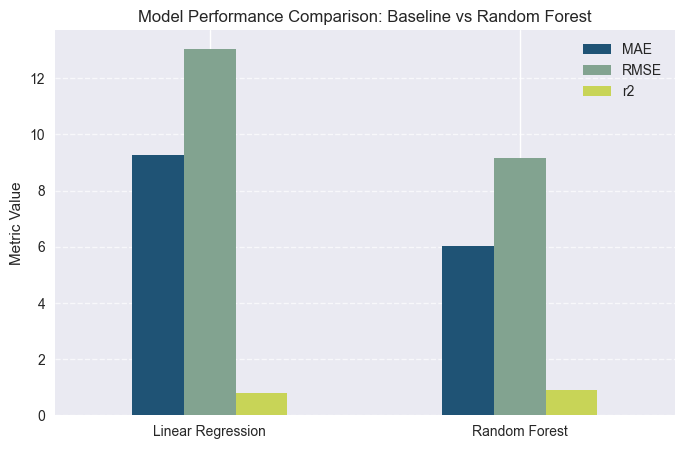

In [38]:
plt.style.use("seaborn-v0_8")
compared_df.plot(kind="bar", figsize=(8,5), color=["#1F5375", "#82A390", "#C8D457"])
plt.title("Model Performance Comparison: Baseline vs Random Forest")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()
plt.show()

In [40]:
mae_diff = baseline_metrics["MAE"] - rf_metrics["MAE"]
rmse_diff = baseline_metrics["RMSE"] - rf_metrics["RMSE"]
r2_diff = rf_metrics["r2"] - baseline_metrics["r2"]

info("Model Performance Improvement Summary:")
success(f"MAE decreased by  {mae_diff:.2f}")
success(f"RMSE decreased by {rmse_diff:.2f}")
success(f"R² increased by   {r2_diff:.3f}")

💬 Model Performance Improvement Summary:
✅ MAE decreased by  3.22
✅ RMSE decreased by 3.89
✅ R² increased by   0.097


## 🌟 07 — Feature Importance Analysis

Description:

- Visualize feature importances and interpret key contributors to AQI predictions.

In [45]:
# === 1. — Extract and Rank Feature Importances ===
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

info("Top 15 Important Features:")
importance_df.head(15)

💬 Top 15 Important Features:


,Feature,Importance
5,pm2.5,0.679679
26,pm2.5_rolling_3d,0.120426
3,o3_8hr,0.094297
10,co_8hr,0.017608
4,pm10,0.009816
27,pm2.5_rolling_7d,0.007240
25,pm10_rolling_7d,0.006634
11,longitude,0.005806
1,co,0.005433
14,month,0.004640


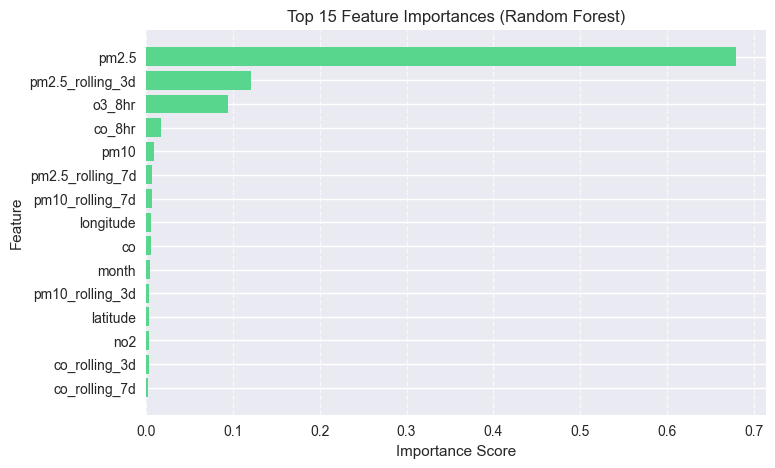

In [49]:
# === 2. — Visualize Feature Importances ===
plt.figure(figsize=(8,5))
top_n = 15
plt.barh(
    importance_df["Feature"].head(top_n)[::-1],
    importance_df["Importance"].head(top_n)[::-1],
    color="#58D68D"
)
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

In [59]:
# === 3. Grouped Feature Importance ===
importance_df["Group"] = importance_df["Feature"].str.extract(r"(pm2\.5|pm10|no2|o3|so2|co|wind|latitude|longitude|month)")
grouped = importance_df.groupby("Group")["Importance"].sum().sort_values(ascending=False).reset_index()
grouped

,Group,Importance
0,pm2.5,0.807345
1,o3,0.101164
2,co,0.028660
3,pm10,0.020503
4,no2,0.006896
5,longitude,0.005806
6,so2,0.004692
7,month,0.004640
8,wind,0.004399
9,latitude,0.003394


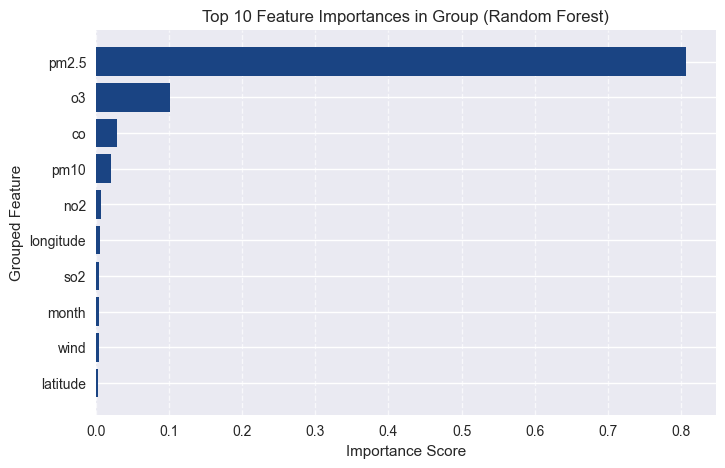

In [58]:
plt.figure(figsize=(8,5))
top_n = 10
plt.barh(
    grouped["Group"].head(top_n)[::-1],
    grouped["Importance"].head(top_n)[::-1],
    color="#1A4483"
)
plt.title(f"Top {top_n} Feature Importances in Group (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Grouped Feature")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

### Interpretation Summary

| Category | Example Features | Insights |
|-----------|------------------|----------|
| **Fine Particulates** | pm2.5, pm10 | Dominant influence on AQI — model correctly focuses on particle concentration. |
| **Temporal Trend** | pm2.5_rolling_3d, pm10_rolling_7d | Reflects accumulated pollution effects across days. |
| **Gaseous Pollutants** | o3_8hr, co_8hr | Secondary factors linked to photochemical and combustion activities. |
| **Spatial / Temporal** | longitude, latitude, month | Capture location- and season-specific variations. |

## 🪞 08 — Error Diagnostics

Description:

- Inspect residuals and high-error regions to understand model limitations.

## 💾 09 — Save Model and Metrics

Description:

- Save the trained Random Forest model and evaluation metrics for reproducibility.

## 🧠 10 — Discussion and Next Chapter

Description:

- Summarize the findings, discuss performance improvements, and introduce Chapter 05 – Model Optimization.